# HW05: Build & Compare NN vs CNN (Fashion MNIST)

**Student Name / ID:** 吳沛恩 113511103

**Date:** Nov 2025

## 1. Problem & Data
This notebook implements both Fully Connected Neural Networks (NN) and Convolutional Neural Networks (CNN) to classify the Fashion-MNIST dataset. We will compare their performance, analyze the effects of various architectural decisions (BatchNorm, Dropout, Residual connections), and generate predictions for Kaggle.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from tqdm.notebook import tqdm  # Use notebook version of tqdm
from sklearn.metrics import confusion_matrix

# Set Random Seed for Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(56)

# Device Configuration for GPU/MPS
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("✅ Using Mac MPS acceleration")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("✅ Using NVIDIA CUDA")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Using CPU")

CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


✅ Using Mac MPS acceleration


In [2]:
class FashionMNISTDataset(Dataset):
    def __init__(self, csv_file, mode='train', transform=None, model_type='nn'):
        self.data = pd.read_csv(csv_file)
        self.mode = mode
        self.transform = transform
        self.model_type = model_type
        
        if self.mode == 'train':
            self.labels = self.data.iloc[:, 0].values
            self.pixels = self.data.iloc[:, 1:].values
        else:
            # Test set: id in col 0, pixels from col 2 (ignore col 1 label placeholder if any)
            self.ids = self.data.iloc[:, 0].values
            self.pixels = self.data.iloc[:, 2:].values
        
    def __len__(self):
        return len(self.pixels)
        
    def __getitem__(self, idx):
        pixel_data = self.pixels[idx]
        img_array = pixel_data.reshape(28, 28).astype(np.uint8)
        
        if self.transform:
            img_tensor = self.transform(img_array)
        else:
            img_tensor = torch.from_numpy(img_array.astype('float32') / 255.0)
            img_tensor = img_tensor.unsqueeze(0)
        
        if self.model_type == 'nn':
            img_tensor = img_tensor.flatten()
        
        if self.mode == 'train':
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return img_tensor, label
        else:
            return img_tensor, self.ids[idx]

# Define Transforms
# Training transform with augmentation
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(28, padding=2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), value=0)
])

# Validation/Test transform (No augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


Loading Data...
Training samples: 54000
Validation samples: 6000
Sample Training Images:


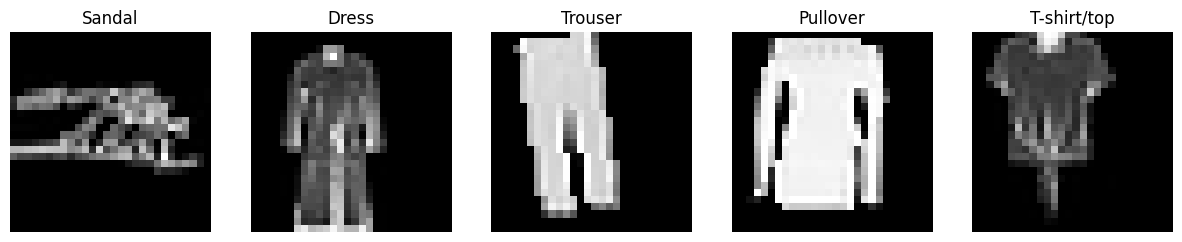

In [ ]:
# Load Dataset
print("Loading Data...")
full_dataset = FashionMNISTDataset("data/train.csv", mode='train', transform=None, model_type='cnn')

val_size = int(0.15 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_indices, val_indices = random_split(
    range(len(full_dataset)), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create Datasets with Transforms
train_dataset = FashionMNISTDataset("data/train.csv", mode='train', transform=train_transform, model_type='cnn')
val_dataset = FashionMNISTDataset("data/train.csv", mode='train', transform=val_transform, model_type='cnn')

train_set = Subset(train_dataset, train_indices.indices)
val_set = Subset(val_dataset, val_indices.indices)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")

# Visualize some samples
def show_samples(loader, count=5):
    inputs, labels = next(iter(loader))
    plt.figure(figsize=(15, 3))
    for i in range(count):
        plt.subplot(1, count, i+1)
        img = inputs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5 # Un-normalize
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(CLASSES[labels[i]])
        plt.axis('off')
    plt.show()

print("Sample Training Images:")
show_samples(train_loader)


## 2. Model Architectures


In [4]:
# 1. Baseline CNN (Standard)
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # Standard Conv -> ReLU -> MaxPool -> ... -> Linear
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

# 1b. Baseline NN (MLP)
class BaselineNN(nn.Module):
    def __init__(self):
        super(BaselineNN, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# 2. Improved NN
class ImprovedNN(nn.Module):
    def __init__(self, use_bn=True, use_dropout=True):
        super(ImprovedNN, self).__init__()
        self.use_bn = use_bn
        self.use_dropout = use_dropout
        
        layers = []
        # Block 1
        layers.append(nn.Linear(784, 1024))
        if self.use_bn: layers.append(nn.BatchNorm1d(1024))
        layers.append(nn.ReLU())
        if self.use_dropout: layers.append(nn.Dropout(0.3))
            
        # Block 2
        layers.append(nn.Linear(1024, 512))
        if self.use_bn: layers.append(nn.BatchNorm1d(512))
        layers.append(nn.ReLU())
        if self.use_dropout: layers.append(nn.Dropout(0.3))
            
        # Block 3
        layers.append(nn.Linear(512, 256))
        if self.use_bn: layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if self.use_dropout: layers.append(nn.Dropout(0.3))
            
        layers.append(nn.Linear(256, 10))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

# 2b. Improved CNN
class ImprovedCNN(nn.Module):
    def __init__(self, use_bn=True, use_dropout=True, use_residual=False, pooling_type='max'):
        super(ImprovedCNN, self).__init__()
        self.use_bn = use_bn
        self.use_dropout = use_dropout
        self.use_residual = use_residual
        self.pooling_type = pooling_type

        def create_conv_layer(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False)]
            if self.use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return nn.Sequential(*layers)

        self.block1_conv1 = create_conv_layer(1, 32)
        self.block1_conv2 = create_conv_layer(32, 32)
        if self.use_residual: self.res1 = nn.Conv2d(1, 32, kernel_size=1, bias=False)
        
        if self.pooling_type == 'max': self.pool1 = nn.MaxPool2d(2, 2)
        elif self.pooling_type == 'stride': self.pool1 = nn.Conv2d(32, 32, 3, 2, 1)
        else: self.pool1 = nn.Identity()

        self.block2_conv1 = create_conv_layer(32, 64)
        self.block2_conv2 = create_conv_layer(64, 64)
        if self.use_residual: self.res2 = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        
        if self.pooling_type == 'max': self.pool2 = nn.MaxPool2d(2, 2)
        elif self.pooling_type == 'stride': self.pool2 = nn.Conv2d(64, 64, 3, 2, 1)
        else: self.pool2 = nn.Identity()
        
        self.block3_conv1 = create_conv_layer(64, 128)
        self.block3_conv2 = create_conv_layer(128, 256)
        if self.use_residual: self.res3 = nn.Conv2d(64, 256, kernel_size=1, bias=False)
        
        self.gap = nn.AdaptiveAvgPool2d(1)
        if self.use_dropout: self.dropout = nn.Dropout(0.2)
        else: self.dropout = nn.Identity()
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1
        identity = x
        out = self.block1_conv1(x)
        out = self.block1_conv2(out)
        if self.use_residual:
            identity = self.res1(identity)
            out = out + identity
        out = self.pool1(out)

        # Block 2
        identity = out
        out = self.block2_conv1(out)
        out = self.block2_conv2(out)
        if self.use_residual:
            identity = self.res2(identity)
            out = out + identity
        out = self.pool2(out)

        # Block 3
        identity = out
        out = self.block3_conv1(out)
        out = self.block3_conv2(out)
        if self.use_residual:
            identity = self.res3(identity)
            out = out + identity
        
        out = self.gap(out)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out


In [5]:
class EarlyStopping:
    def __init__(self, patience=15, verbose=False, delta=0, path='best_checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        import os
        save_dir = "checkpoints"
        os.makedirs(save_dir, exist_ok=True)
        self.path = os.path.join(save_dir, path)

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    return avg_loss, acc

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(val_loader)
    acc = 100 * correct / total
    return avg_loss, acc

def run_training(model, train_loader, val_loader, epochs=35, lr=1e-3, model_name="model"):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    early_stopping = EarlyStopping(patience=10, verbose=True, path=f'{model_name}_best.pth')
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"🚀 Training {model_name} on {DEVICE}...")
    print(f"{'Epoch':^7} | {'Train Loss':^12} | {'Train Acc':^11} | {'Val Loss':^12} | {'Val Acc':^11} | {'LR':^10}")
    print("-" * 85)
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, DEVICE)
        
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"{epoch+1:^7} | {train_loss:^12.4f} | {train_acc:^10.2f}% | {val_loss:^12.4f} | {val_acc:^10.2f}% | {current_lr:^10.6f}")
            
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("⚠️ Early stopping triggered")
            break
            
    model.load_state_dict(torch.load(early_stopping.path))
    return history


## 3. Part A: Baselines
We train the Baseline NN (MLP) and Baseline CNN to establish a performance benchmark.


🚀 Training BaselineNN on mps...
 Epoch  |  Train Loss  |  Train Acc  |   Val Loss   |   Val Acc   |     LR    
-------------------------------------------------------------------------------------
   1    |    1.2660    |   64.09   % |    1.0398    |   75.10   % |  0.001000 
Validation loss decreased (inf --> 1.039826). Saving model...
   2    |    1.1301    |   70.41   % |    1.0033    |   75.48   % |  0.000998 
Validation loss decreased (1.039826 --> 1.003348). Saving model...
   3    |    1.0924    |   72.06   % |    0.9537    |   78.22   % |  0.000992 
Validation loss decreased (1.003348 --> 0.953720). Saving model...
   4    |    1.0674    |   73.09   % |    0.9310    |   79.93   % |  0.000982 
Validation loss decreased (0.953720 --> 0.931015). Saving model...
   5    |    1.0507    |   73.94   % |    0.9022    |   81.18   % |  0.000968 
Validation loss decreased (0.931015 --> 0.902153). Saving model...
   6    |    1.0352    |   74.63   % |    0.9062    |   81.50   % |  0.000950 

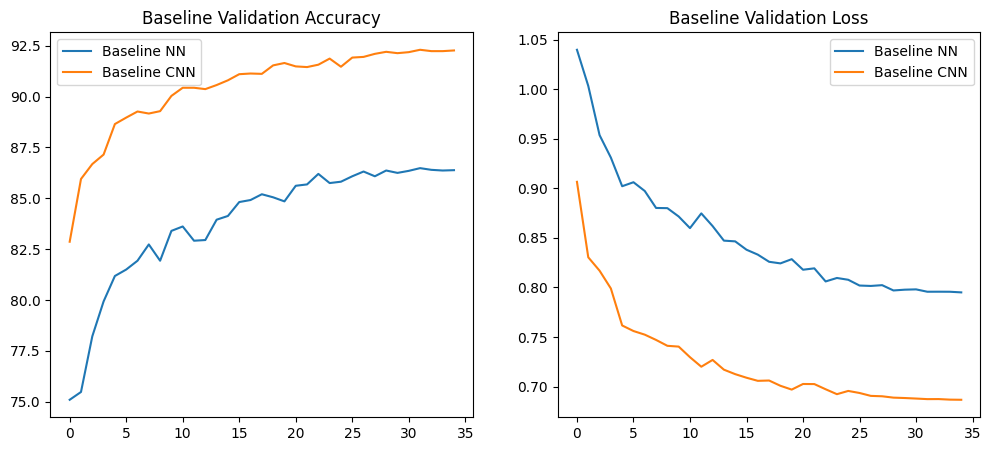

In [6]:
# Train Baseline NN
baseline_nn = BaselineNN().to(DEVICE)
nn_history = run_training(baseline_nn, train_loader, val_loader, epochs=35, model_name="BaselineNN")

# Train Baseline CNN
baseline_cnn = BaselineCNN().to(DEVICE)
cnn_history = run_training(baseline_cnn, train_loader, val_loader, epochs=35, model_name="BaselineCNN")

# Plot Baselines
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(nn_history['val_acc'], label='Baseline NN')
plt.plot(cnn_history['val_acc'], label='Baseline CNN')
plt.title('Baseline Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(nn_history['val_loss'], label='Baseline NN')
plt.plot(cnn_history['val_loss'], label='Baseline CNN')
plt.title('Baseline Validation Loss')
plt.legend()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/baseline_comparison.png', dpi=300)
plt.show()


## 4. Part B: Ablation Studies
We evaluate the impact of Batch Normalization (BN), Dropout, Residual connections, and Pooling strategies.


In [7]:
def run_experiment(config_name, model_cls, model_params, epochs=35):
    print(f"\n🧪 Experiment: {config_name}")
    model = model_cls(**model_params).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params: {total_params:,}")
    
    history = run_training(model, train_loader, val_loader, epochs=epochs, model_name=config_name)
    best_acc = max(history['val_acc'])
    return {'name': config_name, 'params': total_params, 'best_val_acc': best_acc, 'history': history}

experiments_list = [
    # CNN Ablations
    {"name": "CNN_Full",       "cls": ImprovedCNN, "params": {"use_bn": True,  "use_dropout": True,  "use_residual": True,  "pooling_type": 'max'}},
    {"name": "CNN_No_BN",      "cls": ImprovedCNN, "params": {"use_bn": False, "use_dropout": True,  "use_residual": True,  "pooling_type": 'max'}},
    {"name": "CNN_No_Drop",    "cls": ImprovedCNN, "params": {"use_bn": True,  "use_dropout": False, "use_residual": True,  "pooling_type": 'max'}},
    {"name": "CNN_No_Res",     "cls": ImprovedCNN, "params": {"use_bn": True,  "use_dropout": True,  "use_residual": False, "pooling_type": 'max'}},
    {"name": "CNN_Stride",     "cls": ImprovedCNN, "params": {"use_bn": True,  "use_dropout": True,  "use_residual": True,  "pooling_type": 'stride'}},
    
    # NN Ablations
    {"name": "NN_Full",        "cls": ImprovedNN,  "params": {"use_bn": True,  "use_dropout": True}},
    {"name": "NN_No_BN",       "cls": ImprovedNN,  "params": {"use_bn": False, "use_dropout": True}},
]

results = {}
for exp in experiments_list:
    results[exp['name']] = run_experiment(exp['name'], exp['cls'], exp['params'])



🧪 Experiment: CNN_Full
Params: 455,626
🚀 Training CNN_Full on mps...
 Epoch  |  Train Loss  |  Train Acc  |   Val Loss   |   Val Acc   |     LR    
-------------------------------------------------------------------------------------
   1    |    1.0425    |   76.15   % |    0.9358    |   81.00   % |  0.001000 
Validation loss decreased (inf --> 0.935807). Saving model...
   2    |    0.8916    |   83.24   % |    0.8396    |   86.03   % |  0.000998 
Validation loss decreased (0.935807 --> 0.839588). Saving model...
   3    |    0.8488    |   85.22   % |    0.8526    |   86.45   % |  0.000992 
   4    |    0.8188    |   86.41   % |    0.8037    |   87.48   % |  0.000982 
Validation loss decreased (0.839588 --> 0.803686). Saving model...
   5    |    0.7998    |   87.31   % |    0.7879    |   88.42   % |  0.000968 
Validation loss decreased (0.803686 --> 0.787860). Saving model...
   6    |    0.7852    |   88.07   % |    0.7779    |   88.62   % |  0.000950 
Validation loss decreased (0

KeyboardInterrupt: 

## 5. Part C: Results & Analysis


In [ ]:
# Summary Table
data = []

# Find best model based on Validation Accuracy
best_model_name = max(results, key=lambda x: results[x]['best_val_acc'])
best_res = results[best_model_name]
best_params = best_res['params']
best_acc = best_res['best_val_acc']

print(f"🏆 Best Model: {best_model_name} (Acc: {best_acc:.2f}%, Params: {best_params:,})")

for name, res in results.items():
    # Calculate Deltas
    delta_params = res['params'] - best_params
    delta_acc = res['best_val_acc'] - best_acc
    
    data.append({
        'Model': name,
        'Params': f"{res['params']:,}",
        'Δ Params': f"{delta_params:+,}",
        'Best Val Acc (%)': f"{res['best_val_acc']:.2f}",
        'Δ Acc (%)': f"{delta_acc:+.2f}",
    })

df_results = pd.DataFrame(data)
display(df_results)

# Save Table as Image
fig, ax = plt.subplots(figsize=(14, 6)) 
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_results.values, colLabels=df_results.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.8)
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/ablation_table.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Confusion Matrix Comparison (Baseline NN vs Best Improved CNN)
def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

# 1. Load Baseline NN
baseline_nn = BaselineNN().to(DEVICE)
try:
    baseline_nn.load_state_dict(torch.load('checkpoints/BaselineNN_best.pth'))
    print("✅ Loaded Baseline NN")
except FileNotFoundError:
    print("⚠️ Baseline NN checkpoint not found. Please run Part A first.")

# 2. Load Best Improved CNN
best_cnn = ImprovedCNN(use_bn=True, use_dropout=True, use_residual=True, pooling_type='max').to(DEVICE)
try:
    best_cnn.load_state_dict(torch.load('checkpoints/CNN_Full_best.pth'))
    print("✅ Loaded Best Improved CNN")
except FileNotFoundError:
    print("⚠️ Best CNN checkpoint not found. Please run Part B first.")

# Get Predictions
labels_nn, preds_nn = get_all_preds(baseline_nn, val_loader)
labels_cnn, preds_cnn = get_all_preds(best_cnn, val_loader)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Baseline NN
cm_nn = confusion_matrix(labels_nn, preds_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Baseline NN Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Best CNN
cm_cnn = confusion_matrix(labels_cnn, preds_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Improved CNN Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/confusion_matrix_comparison.png', dpi=300)
plt.show()



## 6. Part D: Final Training for Kaggle
We retrain the best model architecture (CNN_Full) with more epochs (60) to maximize performance for the Kaggle submission.


In [ ]:
epochs = 60
# Final Training for Kaggle Submission
print(f"🚀 Starting Final Training for Kaggle ({epochs} Epochs)...")

# Re-initialize the best model architecture
set_seed(56)
final_model = ImprovedCNN(use_bn=True, use_dropout=True, use_residual=True, pooling_type='stride').to(DEVICE)

# Train for 60 epochs with Early Stopping (Patience=15)
# We use a separate run_training call here to ensure we get the best weights
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
early_stopping = EarlyStopping(patience=15, verbose=True, path='final_best_model.pth')

# History tracking
final_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':^7} | {'Train Loss':^12} | {'Train Acc':^11} | {'Val Loss':^12} | {'Val Acc':^11} | {'LR':^10}")
print("-" * 85)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(final_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate_one_epoch(final_model, val_loader, criterion, DEVICE)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    # Record history
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    final_history['val_loss'].append(val_loss)
    final_history['val_acc'].append(val_acc)
    
    print(f"{epoch+1:^7} | {train_loss:^12.4f} | {train_acc:^10.2f}% | {val_loss:^12.4f} | {val_acc:^10.2f}% | {current_lr:^10.6f}")
    
    early_stopping(val_loss, final_model)
    if early_stopping.early_stop:
        print("⚠️ Early stopping triggered")
        break

# Load the best weights from this long training run
final_model.load_state_dict(torch.load('checkpoints/final_best_model.pth'))
print("🏆 Loaded best model from 'final_best_model.pth'")

# Plot Learning Curves (Train vs Val)
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(final_history['train_loss'], label='Train Loss', color='blue', alpha=0.7)
plt.plot(final_history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('Learning Curve: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(final_history['train_acc'], label='Train Acc', color='blue', alpha=0.7)
plt.plot(final_history['val_acc'], label='Val Acc', color='orange', linestyle='--')
plt.title('Learning Curve: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/final_learning_curves.png', dpi=300)
plt.show()



## 7. Part E: Kaggle Submission (TTA)
We generate predictions using Test Time Augmentation (TTA) for better robustness.


In [ ]:
def generate_predictions_TTA(model, test_loader, device, output_file='pred.csv'):
    print("🔮 Generating predictions with TTA...")
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for inputs, ids in tqdm(test_loader, desc="Predicting"):
            inputs = inputs.to(device)
            
            # Original
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            # Flip Augmentation
            inputs_flip = torch.flip(inputs, dims=[3])
            outputs_flip = model(inputs_flip)
            probs_flip = F.softmax(outputs_flip, dim=1)
            
            # Average
            avg_probs = (probs + probs_flip) / 2.0
            _, predicted = torch.max(avg_probs, 1)
            
            for id_val, pred_val in zip(ids, predicted):
                predictions.append((id_val.item(), pred_val.item()))
    
    df = pd.DataFrame(predictions, columns=['idx', 'label'])
    df.to_csv(output_file, index=False)
    print(f"✅ Saved to {output_file}")

# Load Test Data
test_dataset = FashionMNISTDataset("data/test4students.csv", mode='test', transform=val_transform, model_type='cnn')
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Generate predictions using the final trained model
import os
os.makedirs('submissions', exist_ok=True)
generate_predictions_TTA(final_model, test_loader, DEVICE, output_file='submissions/pred.csv')
